# Notebook 72 - Low-level TimTrack MATLAB export parity

This notebook uses the MATLAB debug export created from `filter_usimage_debug.m` on `UltraTimTrack_test.mp4`.

The goal is to isolate the first image-processing mismatch from the parity ladder:

1. Test the Python `dohough` port on MATLAB's exact exported `fascicle_masked` mask.
2. Test the Python `get_fasMask` port using MATLAB's exported `fas_thres`, `super_vec`, and `deep_vec`.
3. Run the independent Python low-level pipeline on the same frames and compare every intermediate mask and Hough variable.

If the same-mask Hough control passes but the full Python path fails, the drift starts upstream of `dohough`, in filtering, adaptive thresholding, aponeurosis line detection, or fascicle masking.

In [1]:
from __future__ import annotations

import math
import sys
import textwrap
from pathlib import Path

import cv2
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import loadmat

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ultrasound_tracker.matlab_timtrack import (
    filter_usimage_hough_matlab_like,
    get_fascicle_mask_matlab_like,
)
from ultrasound_tracker.timtrack_hough import DoHoughParams, dohough, weighted_median

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 80)
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 200})

In [2]:
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

VIDEO_PATH = ROOT / "data" / "raw" / "UltraTimTrack_test.mp4"
UTT_EXPORT = Path("/Users/grosbedou/Documents/GitHub/UltraTimTrack/UTT_numeric_export.mat")

MATLAB_EXPORT_DIR = ROOT / "results" / "notebook72_timtrack_low_level_matlab_export"
MATLAB_EXPORT_V7 = MATLAB_EXPORT_DIR / "matlab_timtrack_low_level_UltraTimTrack_test_v7.mat"
MATLAB_EXPORT_V73 = MATLAB_EXPORT_DIR / "matlab_timtrack_low_level_UltraTimTrack_test.mat"

OUT_DIR = ROOT / "results" / "notebook72_timtrack_low_level_python_parity"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Video:", VIDEO_PATH, VIDEO_PATH.exists())
print("UTT export:", UTT_EXPORT, UTT_EXPORT.exists())
print("MATLAB v7 export:", MATLAB_EXPORT_V7, MATLAB_EXPORT_V7.exists())
print("MATLAB v7.3 export:", MATLAB_EXPORT_V73, MATLAB_EXPORT_V73.exists())
print("Output dir:", OUT_DIR)

Video: /Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4 True
UTT export: /Users/grosbedou/Documents/GitHub/UltraTimTrack/UTT_numeric_export.mat True
MATLAB v7 export: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook72_timtrack_low_level_matlab_export/matlab_timtrack_low_level_UltraTimTrack_test_v7.mat False
MATLAB v7.3 export: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook72_timtrack_low_level_matlab_export/matlab_timtrack_low_level_UltraTimTrack_test.mat True
Output dir: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook72_timtrack_low_level_python_parity


In [3]:
def _decode_attr_bytes(value):
    if isinstance(value, bytes):
        return value.decode()
    if hasattr(value, "item"):
        item = value.item()
        if isinstance(item, bytes):
            return item.decode()
    return value


def _matlab_class(obj):
    return _decode_attr_bytes(obj.attrs.get("MATLAB_class", b"")) if hasattr(obj, "attrs") else ""


def _matlab_fields(group):
    raw = group.attrs.get("MATLAB_fields", [])
    fields = []
    for item in raw:
        if isinstance(item, np.ndarray):
            fields.append(b"".join(item.tolist()).decode())
        elif isinstance(item, bytes):
            fields.append(item.decode())
        else:
            fields.append(str(item))
    return fields


def _read_h5_dataset(f, ds):
    arr = np.asarray(ds)
    cls = _matlab_class(ds)

    if arr.dtype == object:
        out = []
        for ref in arr.reshape(-1):
            out.append(_read_h5_obj(f, f[ref]) if ref else None)
        return out

    # MATLAB stores numeric arrays in column-major order; h5py exposes the
    # reversed axes. Transpose back to the MATLAB/scipy.loadmat convention.
    if arr.ndim >= 2:
        arr = arr.T

    if cls == "char":
        flat = np.asarray(arr).reshape(-1)
        return "".join(chr(int(x)) for x in flat if int(x) != 0)

    arr = np.squeeze(arr)
    if cls == "logical":
        arr = arr.astype(bool)
    if arr.shape == ():
        return arr.item()
    return arr


def _read_h5_struct(f, group):
    fields = _matlab_fields(group)
    values = {field: _read_h5_obj(f, group[field]) for field in fields if field in group}

    list_lengths = [len(v) for v in values.values() if isinstance(v, list)]
    if list_lengths and len(set(list_lengths)) == 1:
        n = list_lengths[0]
        return [
            {field: (value[i] if isinstance(value, list) else value) for field, value in values.items()}
            for i in range(n)
        ]
    return values


def _read_h5_obj(f, obj):
    if isinstance(obj, h5py.Dataset):
        return _read_h5_dataset(f, obj)
    if isinstance(obj, h5py.Group):
        if _matlab_class(obj) == "struct":
            return _read_h5_struct(f, obj)
        return {key: _read_h5_obj(f, obj[key]) for key in obj.keys()}
    raise TypeError(type(obj))


def load_matlab_debug_export():
    """Load either scipy-readable -v7 or MATLAB -v7.3/HDF5 debug exports."""
    if MATLAB_EXPORT_V7.exists():
        return MATLAB_EXPORT_V7, loadmat(MATLAB_EXPORT_V7, simplify_cells=True)

    if MATLAB_EXPORT_V73.exists():
        with h5py.File(MATLAB_EXPORT_V73, "r") as f:
            data = {key: _read_h5_obj(f, f[key]) for key in f.keys() if key != "#refs#"}
        return MATLAB_EXPORT_V73, data

    raise FileNotFoundError(
        f"No MATLAB debug export found. Expected {MATLAB_EXPORT_V7} or {MATLAB_EXPORT_V73}."
    )

mat_path, mat = load_matlab_debug_export()
print("Loaded", mat_path)
print("MAT keys:", sorted(k for k in mat.keys() if not k.startswith('__')))

Loaded /Users/grosbedou/PycharmProjects/NDORMS/results/notebook72_timtrack_low_level_matlab_export/matlab_timtrack_low_level_UltraTimTrack_test.mat
MAT keys: ['M', 'frames0', 'frames1', 'parms', 'utt_export_path', 'video_path']


In [4]:
def as_entries(M):
    if isinstance(M, dict):
        return [M]
    if isinstance(M, list):
        return M
    arr = np.asarray(M, dtype=object).reshape(-1)
    return [x for x in arr]

entries = as_entries(mat["M"])
frames0 = np.asarray(mat["frames0"], dtype=int).reshape(-1)
frames1 = np.asarray(mat["frames1"], dtype=int).reshape(-1)

print("n exported frames:", len(entries))
print("frames0:", frames0.tolist())
print("entry keys:", sorted(entries[0].keys()))
print("first frame0 from entry:", entries[0]["frame0"])

n exported frames: 15
frames0: [0, 1, 2, 100, 250, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2665]
entry keys: ['Emask', 'Emask_radius', 'alpha', 'alphas', 'apo_deep', 'apo_super', 'apo_thres', 'deep_debug', 'deep_vec', 'dohough_x', 'dohough_y', 'fas_filt', 'fas_thres', 'fas_thres_raw', 'fascicle_masked', 'frame0', 'frame1', 'h_by_angle', 'super_debug', 'super_vec', 'weights']
first frame0 from entry: 0.0


In [5]:
utt = loadmat(UTT_EXPORT, simplify_cells=True)["UTT_numeric_export"]
parms = utt["parms"]
fas_parms = parms["fas"]
apo_parms = parms["apo"]

print("apo method:", apo_parms.get("method"))
print("apo threshold sensitivity:", apo_parms.get("th"))
print("apo apox:", np.asarray(apo_parms.get("apox", [])).reshape(-1))
print("fas threshold sensitivity:", fas_parms.get("th"))
print("fas hough range:", np.asarray(fas_parms.get("range")).reshape(-1))
print("fas thetares/rhores/npeaks:", fas_parms.get("thetares"), fas_parms.get("rhores"), fas_parms.get("npeaks"))

apo method: Hough
apo threshold sensitivity: 0.5
apo apox: [ 20  94 168 242 316 390 464 538 612 686]
fas threshold sensitivity: 0.5
fas hough range: [ 5 60]
fas thetares/rhores/npeaks: 0.5 1 10


In [6]:
def read_rgb_red_frame(video_path: Path, frame0: int) -> np.ndarray:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame0))
    ok, bgr = cap.read()
    cap.release()
    if not ok:
        raise RuntimeError(f"Could not read frame0={frame0}")
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    return rgb[:, :, 0]

sample = read_rgb_red_frame(VIDEO_PATH, int(frames0[0]))
print("sample frame shape/dtype/min/max:", sample.shape, sample.dtype, int(sample.min()), int(sample.max()))

sample frame shape/dtype/min/max: (562, 706) uint8 0 255


In [7]:
def as_bool(x) -> np.ndarray:
    return np.asarray(x).astype(bool)

def as_float(x) -> np.ndarray:
    return np.asarray(x, dtype=float)

def flatten_valid(a, b):
    aa = np.asarray(a, dtype=float).reshape(-1)
    bb = np.asarray(b, dtype=float).reshape(-1)
    n = min(len(aa), len(bb))
    aa = aa[:n]
    bb = bb[:n]
    mask = np.isfinite(aa) & np.isfinite(bb)
    return aa[mask], bb[mask]

def numeric_metrics(name, frame0, matlab_value, python_value, unit=""):
    m, p = flatten_valid(matlab_value, python_value)
    diff = p - m
    return {
        "frame0": int(frame0),
        "stage": name,
        "kind": "numeric",
        "unit": unit,
        "n": int(diff.size),
        "matlab_mean": float(np.mean(m)) if diff.size else np.nan,
        "python_mean": float(np.mean(p)) if diff.size else np.nan,
        "bias_py_minus_mat": float(np.mean(diff)) if diff.size else np.nan,
        "mae": float(np.mean(np.abs(diff))) if diff.size else np.nan,
        "rmse": float(np.sqrt(np.mean(diff ** 2))) if diff.size else np.nan,
        "max_abs": float(np.max(np.abs(diff))) if diff.size else np.nan,
        "corr": float(np.corrcoef(m, p)[0, 1]) if diff.size > 1 and np.std(m) > 0 and np.std(p) > 0 else np.nan,
    }

def binary_metrics(name, frame0, matlab_mask, python_mask):
    m = as_bool(matlab_mask)
    p = as_bool(python_mask)
    if m.shape != p.shape:
        raise ValueError(f"shape mismatch for {name}: {m.shape} vs {p.shape}")
    inter = np.logical_and(m, p).sum()
    union = np.logical_or(m, p).sum()
    msum = m.sum()
    psum = p.sum()
    diff = np.logical_xor(m, p).sum()
    denom = msum + psum
    return {
        "frame0": int(frame0),
        "stage": name,
        "kind": "binary",
        "unit": "fraction/pixels",
        "n": int(m.size),
        "matlab_mean": float(m.mean()),
        "python_mean": float(p.mean()),
        "bias_py_minus_mat": float(p.mean() - m.mean()),
        "mae": float(diff / m.size),
        "rmse": float(math.sqrt(diff / m.size)),
        "max_abs": float(diff),
        "corr": np.nan,
        "dice": float(2 * inter / denom) if denom else 1.0,
        "jaccard": float(inter / union) if union else 1.0,
        "different_pixels": int(diff),
    }

def peak_vector(values, n=10):
    arr = np.asarray(values, dtype=float).reshape(-1)
    out = np.full(n, np.nan, dtype=float)
    out[:min(n, len(arr))] = arr[:min(n, len(arr))]
    return out

def hough_params_from_parms(fas_parms, emask_radius):
    return DoHoughParams(
        houghangles=str(fas_parms["houghangles"]),
        angle_range=tuple(np.asarray(fas_parms["range"], dtype=float).reshape(-1)),
        thetares=float(fas_parms["thetares"]),
        rhores=float(fas_parms["rhores"]),
        emask_radius=tuple(np.asarray(emask_radius, dtype=float).reshape(-1)[:2]),
        npeaks=int(fas_parms["npeaks"]),
        replace_diagonal_bias=True,
    )

In [8]:
def run_python_low_level(frame0: int):
    image = read_rgb_red_frame(VIDEO_PATH, int(frame0))
    filtered = filter_usimage_hough_matlab_like(
        image,
        parms,
        subtraction_mode="matlab_literal",
    )
    emask, emask_radius, mean_depths = get_fascicle_mask_matlab_like(
        filtered["fas_thres"],
        filtered["super_vec_1b"],
        filtered["deep_vec_1b"],
    )
    fascicle_masked = as_bool(filtered["fas_thres"]) & as_bool(emask)
    hough = dohough(fascicle_masked, hough_params_from_parms(fas_parms, emask_radius))
    return {
        **filtered,
        "Emask": emask,
        "Emask_radius": np.asarray(emask_radius, dtype=float),
        "mean_depths": np.asarray(mean_depths, dtype=float),
        "fascicle_masked": fascicle_masked,
        "hough": hough,
        "alpha": float(hough["alpha"]),
        "image": image,
    }

py_entries = {}
for frame0 in frames0:
    py_entries[int(frame0)] = run_python_low_level(int(frame0))
    print("ran frame0", int(frame0), "alpha", py_entries[int(frame0)]["alpha"])

ran frame0 0 alpha 19.0


ran frame0 1 alpha 19.0


ran frame0 2 alpha 19.0


ran frame0 100 alpha 29.5


ran frame0 250 alpha 20.5


...

ran frame0 1750 alpha 30.5


ran frame0 2000 alpha 33.5


ran frame0 2250 alpha 25.0


ran frame0 2500 alpha 32.0


ran frame0 2665 alpha 20.0


In [9]:
def run_same_mask_hough(entry):
    radius = np.asarray(entry["Emask_radius"], dtype=float).reshape(-1)[:2]
    return dohough(as_bool(entry["fascicle_masked"]), hough_params_from_parms(fas_parms, radius))

def run_rebuilt_get_fasmask_hough(entry):
    emask, radius, mean_depths = get_fascicle_mask_matlab_like(
        as_bool(entry["fas_thres"]),
        as_float(entry["super_vec"]),
        as_float(entry["deep_vec"]),
    )
    masked = as_bool(entry["fas_thres"]) & as_bool(emask)
    hough = dohough(masked, hough_params_from_parms(fas_parms, radius))
    return {"Emask": emask, "Emask_radius": np.asarray(radius), "mean_depths": mean_depths, "fascicle_masked": masked, "hough": hough}

same_mask = {}
rebuilt_mask = {}
for entry in entries:
    frame0 = int(entry["frame0"])
    same_mask[frame0] = run_same_mask_hough(entry)
    rebuilt_mask[frame0] = run_rebuilt_get_fasmask_hough(entry)

print("same-mask control complete")

same-mask control complete


In [10]:
rows = []
control_rows = []

for entry in entries:
    frame0 = int(entry["frame0"])
    py = py_entries[frame0]
    sm = same_mask[frame0]
    rb = rebuilt_mask[frame0]

    # Binary pipeline stages.
    binary_pairs = [
        ("apo_thres", entry["apo_thres"], py["apo_thres"]),
        ("apo_super", entry["apo_super"], py["apo_super"]),
        ("apo_deep", entry["apo_deep"], py["apo_deep"]),
        ("fas_thres_raw", entry["fas_thres_raw"], py["fas_thres_raw"]),
        ("fas_thres", entry["fas_thres"], py["fas_thres"]),
        ("Emask", entry["Emask"], py["Emask"]),
        ("fascicle_masked", entry["fascicle_masked"], py["fascicle_masked"]),
    ]
    for name, m, p in binary_pairs:
        rows.append(binary_metrics(name, frame0, m, p))

    # Numeric pipeline stages.
    rows.extend([
        numeric_metrics("super_vec", frame0, entry["super_vec"], py["super_vec_1b"], "px"),
        numeric_metrics("deep_vec", frame0, entry["deep_vec"], py["deep_vec_1b"], "px"),
        numeric_metrics("fas_filt", frame0, entry["fas_filt"], py["fas_filt"], "Frangi response"),
        numeric_metrics("Emask_radius", frame0, entry["Emask_radius"], py["Emask_radius"], "px"),
        numeric_metrics("alpha_full_python", frame0, entry["alpha"], py["alpha"], "deg"),
        numeric_metrics("alphas_full_python", frame0, peak_vector(entry["alphas"]), peak_vector(py["hough"]["alphas"]), "deg"),
        numeric_metrics("weights_full_python", frame0, peak_vector(entry["weights"]), peak_vector(py["hough"]["weights"]), "votes"),
        numeric_metrics("h_by_angle_full_python", frame0, entry["h_by_angle"], py["hough"]["h_by_angle"], "votes"),
    ])

    control_rows.extend([
        numeric_metrics("control_A_same_matlab_mask_alpha", frame0, entry["alpha"], sm["alpha"], "deg"),
        numeric_metrics("control_A_same_matlab_mask_alphas", frame0, peak_vector(entry["alphas"]), peak_vector(sm["alphas"]), "deg"),
        numeric_metrics("control_A_same_matlab_mask_weights", frame0, peak_vector(entry["weights"]), peak_vector(sm["weights"]), "votes"),
        numeric_metrics("control_A_same_matlab_mask_h_by_angle", frame0, entry["h_by_angle"], sm["h_by_angle"], "votes"),
        numeric_metrics("control_A_same_matlab_mask_X", frame0, entry["dohough_x"], sm["X"], "px"),
        numeric_metrics("control_A_same_matlab_mask_Y", frame0, entry["dohough_y"], sm["Y"], "px"),
        numeric_metrics("control_B_rebuilt_get_fasMask_alpha", frame0, entry["alpha"], rb["hough"]["alpha"], "deg"),
        binary_metrics("control_B_rebuilt_get_fasMask_Emask", frame0, entry["Emask"], rb["Emask"]),
        binary_metrics("control_B_rebuilt_get_fasMask_fascicle_masked", frame0, entry["fascicle_masked"], rb["fascicle_masked"]),
        numeric_metrics("control_C_full_python_alpha", frame0, entry["alpha"], py["alpha"], "deg"),
    ])

metrics = pd.DataFrame(rows)
controls = pd.DataFrame(control_rows)

metrics.to_csv(OUT_DIR / "frame_stage_metrics.csv", index=False)
controls.to_csv(OUT_DIR / "hough_control_metrics.csv", index=False)

print("metrics rows", len(metrics), "controls rows", len(controls))
display(metrics.head(12))
display(controls.head(12))

metrics rows 225 controls rows 150


,frame0,stage,kind,unit,n,matlab_mean,python_mean,bias_py_minus_mat,mae,rmse,max_abs,corr,dice,jaccard,different_pixels
0,0,apo_thres,binary,fraction/pixels,396772,0.931618,0.324000,-0.607618,0.607618,0.779499,241086.000000,NaN,0.516080,0.347782,241086.0
1,0,apo_super,binary,fraction/pixels,396772,0.113909,0.037586,-0.076323,0.076323,0.276267,30283.000000,NaN,0.496199,0.329963,30283.0
2,0,apo_deep,binary,fraction/pixels,396772,0.125959,0.042493,-0.083466,0.083466,0.288905,33117.000000,NaN,0.504511,0.337355,33117.0
3,0,fas_thres_raw,binary,fraction/pixels,396772,0.227932,0.232952,0.005021,0.006230,0.078932,2472.000000,NaN,0.986482,0.973324,2472.0
4,0,fas_thres,binary,fraction/pixels,396772,0.227932,0.232952,0.005021,0.006230,0.078932,2472.000000,NaN,0.986482,0.973324,2472.0
5,0,Emask,binary,fraction/pixels,396772,0.323934,0.385607,0.061673,0.061733,0.248462,24494.000000,NaN,0.912996,0.839919,24494.0
6,0,fascicle_masked,binary,fraction/pixels,396772,0.063288,0.074514,0.011226,0.011866,0.108930,4708.000000,NaN,0.913893,0.841439,4708.0
7,0,super_vec,numeric,px,10,64.300000,46.400000,-17.900000,26.300000,27.171676,42.000000,-0.547249,NaN,NaN,NaN
8,0,deep_vec,numeric,px,10,295.600000,321.600000,26.000000,26.000000,27.575351,42.000000,-0.274581,NaN,NaN,NaN
9,0,fas_filt,numeric,Frangi response,396772,0.118673,0.117680,-0.000992,0.001127,0.002399,0.117345,0.999966,NaN,NaN,NaN


,frame0,stage,kind,unit,n,matlab_mean,python_mean,bias_py_minus_mat,mae,rmse,max_abs,corr,dice,jaccard,different_pixels
0,0,control_A_same_matlab_mask_alpha,numeric,deg,1,19.500000,21.000000,1.500000,1.500000,1.500000,1.5,NaN,NaN,NaN,NaN
1,0,control_A_same_matlab_mask_alphas,numeric,deg,10,18.750000,21.250000,2.500000,4.600000,6.576473,14.5,-0.443165,NaN,NaN,NaN
2,0,control_A_same_matlab_mask_weights,numeric,votes,10,292.700000,298.200000,5.500000,5.500000,7.007139,11.0,0.995587,NaN,NaN,NaN
3,0,control_A_same_matlab_mask_h_by_angle,numeric,votes,111,223.918919,223.918919,0.000000,0.000000,0.000000,0.0,1.000000,NaN,NaN,NaN
4,0,control_A_same_matlab_mask_X,numeric,px,20,378.400000,390.750000,12.350000,97.150000,137.581794,299.0,0.824039,NaN,NaN,NaN
5,0,control_A_same_matlab_mask_Y,numeric,px,20,183.100000,190.800000,7.700000,32.100000,44.734774,104.0,0.843052,NaN,NaN,NaN
6,0,control_B_rebuilt_get_fasMask_alpha,numeric,deg,1,19.500000,21.000000,1.500000,1.500000,1.500000,1.5,NaN,NaN,NaN,NaN
7,0,control_B_rebuilt_get_fasMask_Emask,binary,fraction/pixels,396772,0.323934,0.324121,0.000187,0.000187,0.013657,74.0,NaN,0.999712,0.999425,74.0
8,0,control_B_rebuilt_get_fasMask_fascicle_masked,binary,fraction/pixels,396772,0.063288,0.063306,0.000018,0.000018,0.004200,7.0,NaN,0.999861,0.999721,7.0
9,0,control_C_full_python_alpha,numeric,deg,1,19.500000,19.000000,-0.500000,0.500000,0.500000,0.5,NaN,NaN,NaN,NaN


In [11]:
def aggregate_metrics(df):
    group_cols = ["stage", "kind", "unit"]
    rows = []
    for keys, g in df.groupby(group_cols, dropna=False):
        stage, kind, unit = keys
        row = {
            "stage": stage,
            "kind": kind,
            "unit": unit,
            "frames": int(g["frame0"].nunique()),
            "mean_bias": float(g["bias_py_minus_mat"].mean()),
            "mean_mae": float(g["mae"].mean()),
            "mean_rmse": float(g["rmse"].mean()),
            "worst_mae": float(g["mae"].max()),
            "worst_rmse": float(g["rmse"].max()),
            "worst_max_abs": float(g["max_abs"].max()),
        }
        if "dice" in g:
            row["mean_dice"] = float(g["dice"].mean()) if g["dice"].notna().any() else np.nan
            row["worst_dice"] = float(g["dice"].min()) if g["dice"].notna().any() else np.nan
        rows.append(row)
    return pd.DataFrame(rows).sort_values(["kind", "worst_mae"], ascending=[True, False])

summary = aggregate_metrics(metrics)
control_summary = aggregate_metrics(controls)
summary.to_csv(OUT_DIR / "summary_metrics.csv", index=False)
control_summary.to_csv(OUT_DIR / "hough_control_summary.csv", index=False)

display(control_summary)
display(summary)

,stage,kind,unit,frames,mean_bias,mean_mae,mean_rmse,worst_mae,worst_rmse,worst_max_abs,mean_dice,worst_dice
6,control_B_rebuilt_get_fasMask_Emask,binary,fraction/pixels,15,0.000200,0.000200,0.014078,0.000302,0.017391,120.0,0.999696,0.999547
8,control_B_rebuilt_get_fasMask_fascicle_masked,binary,fraction/pixels,15,0.000025,0.000025,0.004937,0.000050,0.007100,20.0,0.999800,0.999605
0,control_A_same_matlab_mask_X,numeric,px,15,7.326667,74.193333,115.269140,115.500000,160.472739,390.0,NaN,NaN
1,control_A_same_matlab_mask_Y,numeric,px,15,1.960000,18.026667,28.213457,32.100000,44.734774,108.0,NaN,NaN
3,control_A_same_matlab_mask_alphas,numeric,deg,15,1.376667,4.630000,7.082602,9.600000,14.159802,24.5,NaN,NaN
5,control_A_same_matlab_mask_weights,numeric,votes,15,3.780000,3.780000,5.589340,7.200000,10.963576,29.0,NaN,NaN
2,control_A_same_matlab_mask_alpha,numeric,deg,15,1.000000,1.200000,1.200000,6.500000,6.500000,6.5,NaN,NaN
7,control_B_rebuilt_get_fasMask_alpha,numeric,deg,15,1.000000,1.200000,1.200000,6.500000,6.500000,6.5,NaN,NaN
9,control_C_full_python_alpha,numeric,deg,15,-0.233333,0.966667,0.966667,5.500000,5.500000,5.5,NaN,NaN
4,control_A_same_matlab_mask_h_by_angle,numeric,votes,15,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,NaN,NaN


,stage,kind,unit,frames,mean_bias,mean_mae,mean_rmse,worst_mae,worst_rmse,worst_max_abs,mean_dice,worst_dice
6,apo_thres,binary,fraction/pixels,15,-0.582631,0.582631,0.763169,0.613534,0.783284,243433.00000,0.514888,0.502098
4,apo_deep,binary,fraction/pixels,15,-0.076812,0.076812,0.276939,0.086110,0.293445,34166.00000,0.536550,0.490349
5,apo_super,binary,fraction/pixels,15,-0.073038,0.073038,0.270229,0.076424,0.276449,30323.00000,0.505432,0.496070
0,Emask,binary,fraction/pixels,15,0.043995,0.045362,0.210695,0.065932,0.256772,26160.00000,0.935418,0.906159
11,fascicle_masked,binary,fraction/pixels,15,0.006666,0.007829,0.087203,0.011871,0.108953,4710.00000,0.941573,0.913893
9,fas_thres,binary,fraction/pixels,15,0.003318,0.006274,0.079187,0.007175,0.084708,2847.00000,0.984891,0.980831
10,fas_thres_raw,binary,fraction/pixels,15,0.003318,0.006274,0.079187,0.007175,0.084708,2847.00000,0.984891,0.980831
13,super_vec,numeric,px,15,-19.853333,23.146667,23.811732,26.300000,27.171676,42.00000,NaN,NaN
7,deep_vec,numeric,px,15,11.620000,12.833333,14.511447,26.000000,27.575351,42.00000,NaN,NaN
12,h_by_angle_full_python,numeric,votes,15,-5.983183,9.278078,11.052557,12.468468,13.997426,36.00000,NaN,NaN


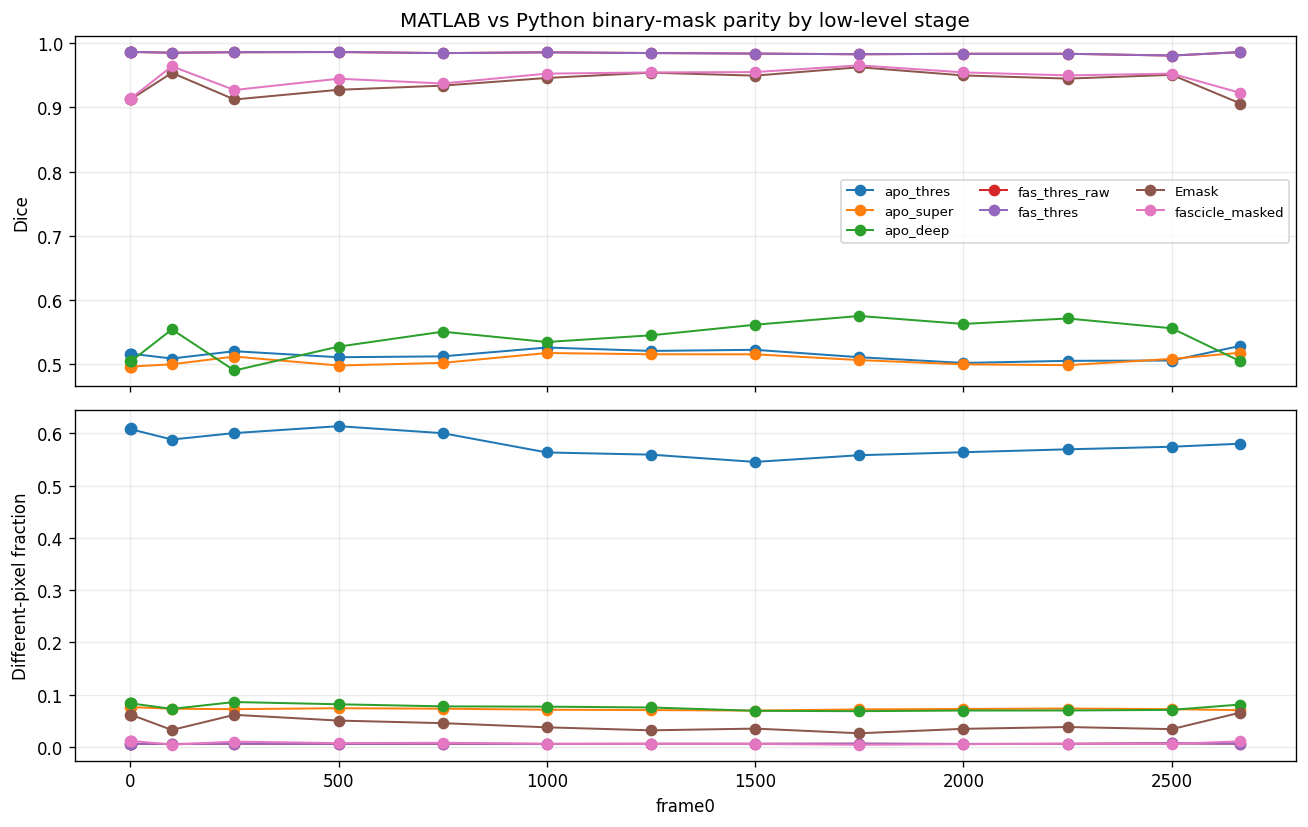

In [12]:
binary_order = ["apo_thres", "apo_super", "apo_deep", "fas_thres_raw", "fas_thres", "Emask", "fascicle_masked"]
plot_df = metrics[(metrics["kind"] == "binary") & metrics["stage"].isin(binary_order)].copy()

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for stage in binary_order:
    g = plot_df[plot_df["stage"] == stage].sort_values("frame0")
    axes[0].plot(g["frame0"], g["dice"], marker="o", linewidth=1.2, label=stage)
    axes[1].plot(g["frame0"], g["mae"], marker="o", linewidth=1.2, label=stage)
axes[0].set_ylabel("Dice")
axes[0].set_title("MATLAB vs Python binary-mask parity by low-level stage")
axes[0].grid(alpha=0.25)
axes[0].legend(ncol=3, fontsize=8)
axes[1].set_ylabel("Different-pixel fraction")
axes[1].set_xlabel("frame0")
axes[1].grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / "mask_stage_disagreement_by_frame.png", bbox_inches="tight")
plt.show()

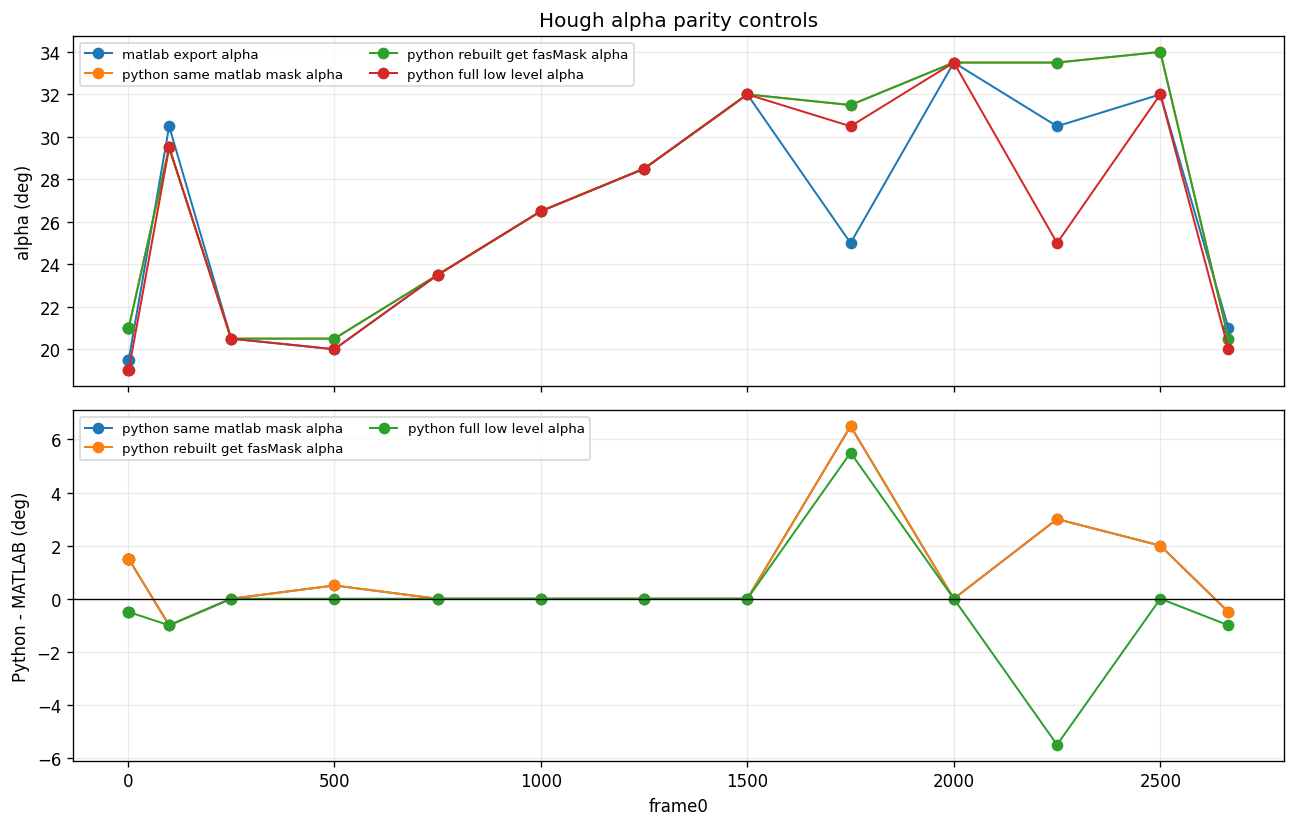

,frame0,matlab_export_alpha,python_same_matlab_mask_alpha,python_rebuilt_get_fasMask_alpha,python_full_low_level_alpha
0,0,19.5,21.0,21.0,19.0
1,1,19.5,21.0,21.0,19.0
2,2,19.5,21.0,21.0,19.0
3,100,30.5,29.5,29.5,29.5
4,250,20.5,20.5,20.5,20.5
5,500,20.0,20.5,20.5,20.0
6,750,23.5,23.5,23.5,23.5
7,1000,26.5,26.5,26.5,26.5
8,1250,28.5,28.5,28.5,28.5
9,1500,32.0,32.0,32.0,32.0


In [13]:
alpha_rows = []
for entry in entries:
    frame0 = int(entry["frame0"])
    alpha_rows.append({
        "frame0": frame0,
        "matlab_export_alpha": float(entry["alpha"]),
        "python_same_matlab_mask_alpha": float(same_mask[frame0]["alpha"]),
        "python_rebuilt_get_fasMask_alpha": float(rebuilt_mask[frame0]["hough"]["alpha"]),
        "python_full_low_level_alpha": float(py_entries[frame0]["alpha"]),
    })
alpha_df = pd.DataFrame(alpha_rows).sort_values("frame0")
alpha_df.to_csv(OUT_DIR / "alpha_controls_by_frame.csv", index=False)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for col in [c for c in alpha_df.columns if c != "frame0"]:
    axes[0].plot(alpha_df["frame0"], alpha_df[col], marker="o", linewidth=1.2, label=col.replace("_", " "))
for col in [c for c in alpha_df.columns if c not in {"frame0", "matlab_export_alpha"}]:
    axes[1].plot(alpha_df["frame0"], alpha_df[col] - alpha_df["matlab_export_alpha"], marker="o", linewidth=1.2, label=col.replace("_", " "))
axes[0].set_ylabel("alpha (deg)")
axes[0].set_title("Hough alpha parity controls")
axes[0].legend(ncol=2, fontsize=8)
axes[0].grid(alpha=0.25)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Python - MATLAB (deg)")
axes[1].set_xlabel("frame0")
axes[1].grid(alpha=0.25)
axes[1].legend(ncol=2, fontsize=8)
fig.tight_layout()
fig.savefig(OUT_DIR / "alpha_stage_parity_by_frame.png", bbox_inches="tight")
plt.show()

display(alpha_df)

worst frame0 by fascicle_masked disagreement: 1


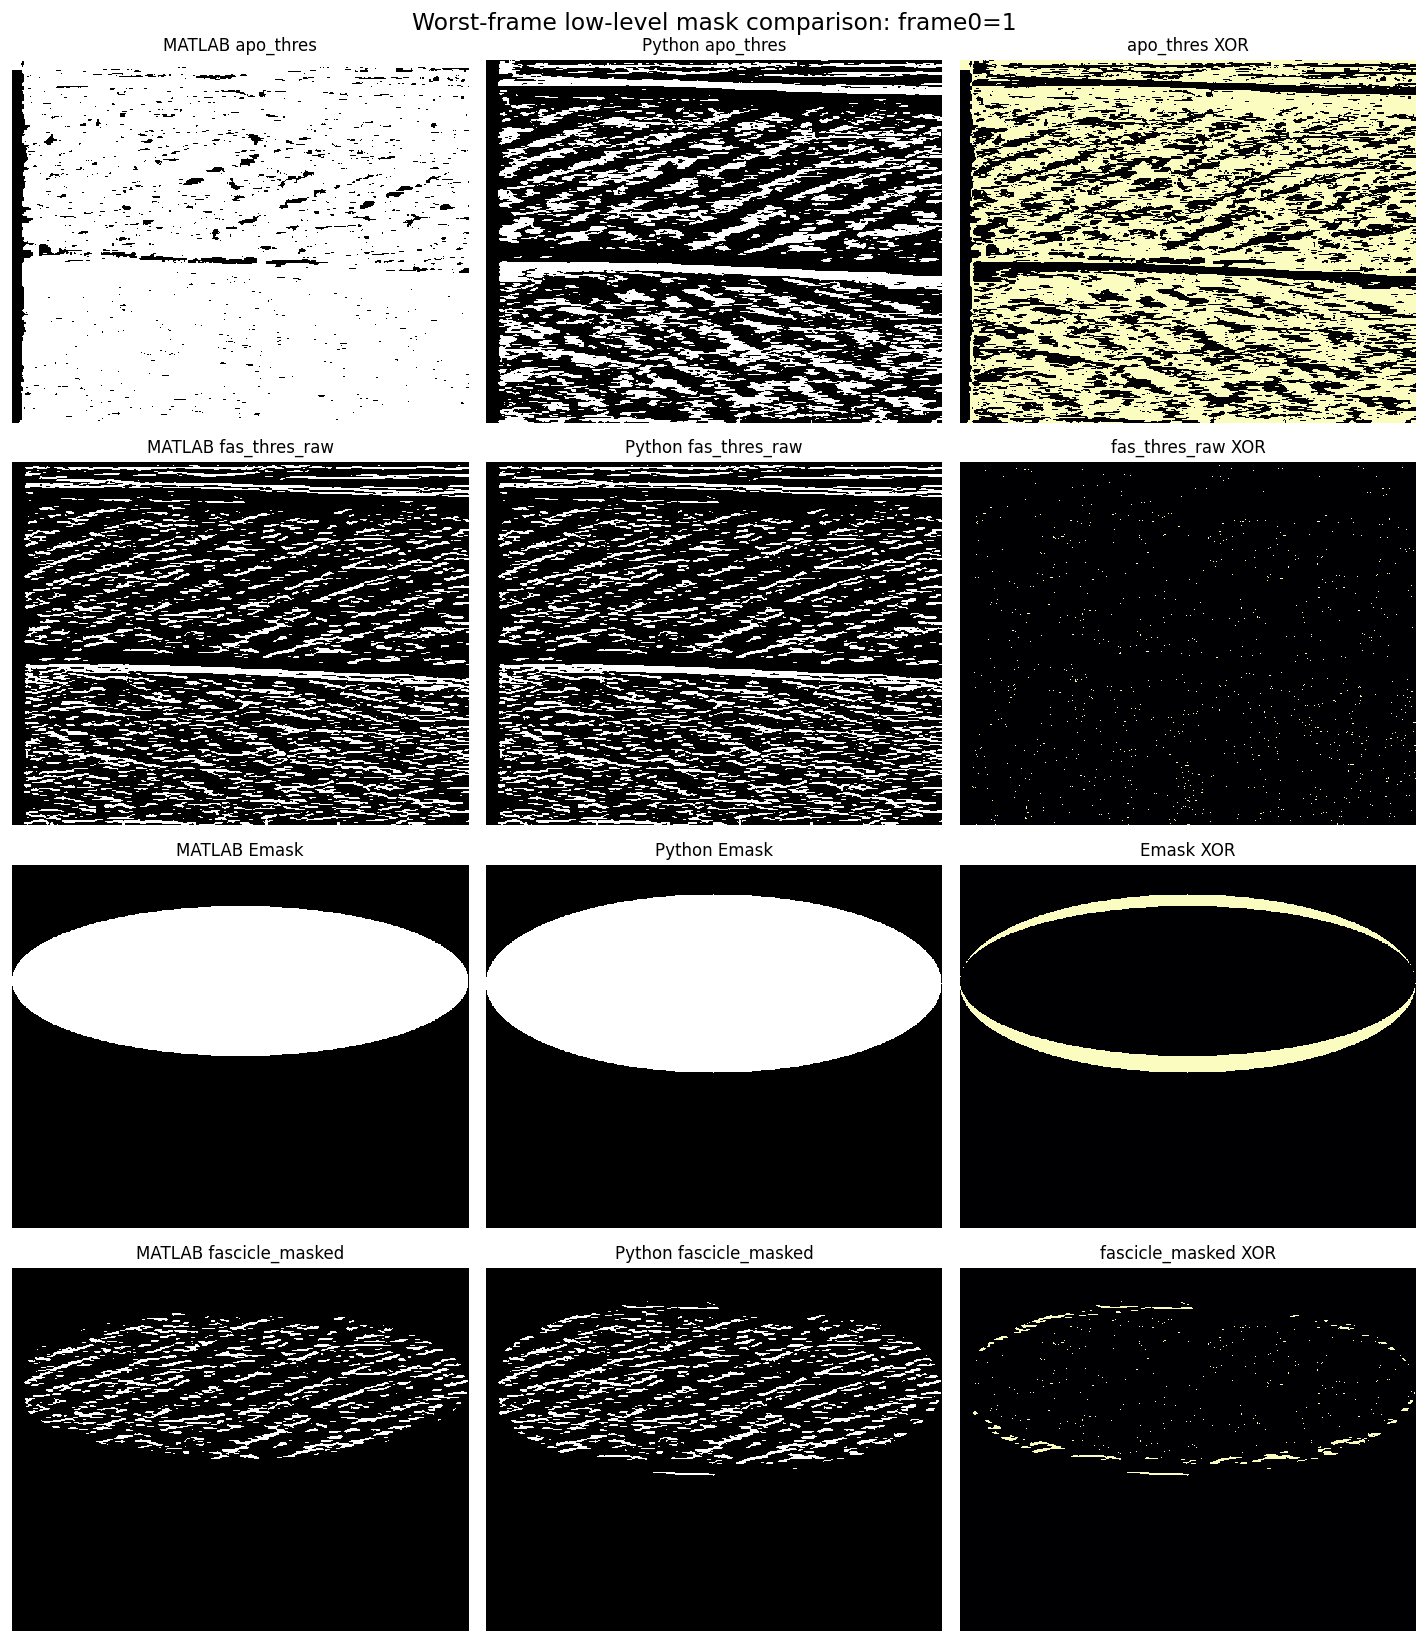

In [14]:
# Pick the worst full-mask disagreement frame for visual inspection.
full_mask = metrics[(metrics["stage"] == "fascicle_masked") & (metrics["kind"] == "binary")].copy()
worst_frame = int(full_mask.sort_values("mae", ascending=False).iloc[0]["frame0"])
entry = next(e for e in entries if int(e["frame0"]) == worst_frame)
py = py_entries[worst_frame]
print("worst frame0 by fascicle_masked disagreement:", worst_frame)

panel_specs = [
    ("MATLAB apo_thres", as_bool(entry["apo_thres"]), "gray"),
    ("Python apo_thres", as_bool(py["apo_thres"]), "gray"),
    ("apo_thres XOR", as_bool(entry["apo_thres"]) ^ as_bool(py["apo_thres"]), "magma"),
    ("MATLAB fas_thres_raw", as_bool(entry["fas_thres_raw"]), "gray"),
    ("Python fas_thres_raw", as_bool(py["fas_thres_raw"]), "gray"),
    ("fas_thres_raw XOR", as_bool(entry["fas_thres_raw"]) ^ as_bool(py["fas_thres_raw"]), "magma"),
    ("MATLAB Emask", as_bool(entry["Emask"]), "gray"),
    ("Python Emask", as_bool(py["Emask"]), "gray"),
    ("Emask XOR", as_bool(entry["Emask"]) ^ as_bool(py["Emask"]), "magma"),
    ("MATLAB fascicle_masked", as_bool(entry["fascicle_masked"]), "gray"),
    ("Python fascicle_masked", as_bool(py["fascicle_masked"]), "gray"),
    ("fascicle_masked XOR", as_bool(entry["fascicle_masked"]) ^ as_bool(py["fascicle_masked"]), "magma"),
]

fig, axes = plt.subplots(4, 3, figsize=(12, 14))
for ax, (title, img, cmap) in zip(axes.ravel(), panel_specs):
    ax.imshow(img, cmap=cmap, interpolation="nearest")
    ax.set_title(title, fontsize=10)
    ax.axis("off")
fig.suptitle(f"Worst-frame low-level mask comparison: frame0={worst_frame}", fontsize=14)
fig.tight_layout()
fig.savefig(OUT_DIR / "worst_frame_mask_panel.png", bbox_inches="tight")
plt.show()

In [15]:
# Hough peak table for the same worst frame.
entry = next(e for e in entries if int(e["frame0"]) == worst_frame)
py = py_entries[worst_frame]
sm = same_mask[worst_frame]
rb = rebuilt_mask[worst_frame]

peak_table = pd.DataFrame({
    "rank": np.arange(1, 11),
    "matlab_alpha": peak_vector(entry["alphas"]),
    "matlab_weight": peak_vector(entry["weights"]),
    "same_mask_py_alpha": peak_vector(sm["alphas"]),
    "same_mask_py_weight": peak_vector(sm["weights"]),
    "rebuilt_mask_py_alpha": peak_vector(rb["hough"]["alphas"]),
    "rebuilt_mask_py_weight": peak_vector(rb["hough"]["weights"]),
    "full_py_alpha": peak_vector(py["hough"]["alphas"]),
    "full_py_weight": peak_vector(py["hough"]["weights"]),
})
peak_table.to_csv(OUT_DIR / "worst_frame_hough_peaks.csv", index=False)
display(peak_table)

,rank,matlab_alpha,matlab_weight,same_mask_py_alpha,same_mask_py_weight,rebuilt_mask_py_alpha,rebuilt_mask_py_weight,full_py_alpha,full_py_weight
0,1,19.0,367.0,19.0,367.0,19.0,367.0,19.0,367.0
1,2,21.0,349.0,21.0,349.0,21.0,349.0,21.0,339.0
2,3,19.0,293.0,19.0,293.0,19.0,293.0,11.0,280.0
3,4,25.5,291.0,25.5,291.0,25.5,291.0,8.5,277.0
4,5,21.0,281.0,20.0,287.0,20.0,287.0,20.0,276.0
5,6,22.0,275.0,20.0,287.0,20.0,287.0,20.0,275.0
6,7,10.5,270.0,21.0,281.0,21.0,281.0,25.5,272.0
7,8,20.5,267.0,22.0,278.0,22.0,278.0,10.5,269.0
8,9,19.5,267.0,22.0,275.0,22.0,275.0,19.0,268.0
9,10,18.5,267.0,23.0,272.0,23.0,272.0,5.5,268.0


In [16]:
# Compact decision report.
ctrl = control_summary.set_index("stage")
sm_alpha = ctrl.loc["control_A_same_matlab_mask_alpha"] if "control_A_same_matlab_mask_alpha" in ctrl.index else None
rb_alpha = ctrl.loc["control_B_rebuilt_get_fasMask_alpha"] if "control_B_rebuilt_get_fasMask_alpha" in ctrl.index else None
full_alpha = ctrl.loc["control_C_full_python_alpha"] if "control_C_full_python_alpha" in ctrl.index else None

lines = []
lines.append("# Notebook 72 summary")
lines.append("")
lines.append(f"MATLAB export: `{mat_path}`")
lines.append(f"Frames: {frames0.tolist()}")
lines.append("")
if sm_alpha is not None:
    lines.append(f"- Same MATLAB mask -> Python dohough alpha: mean MAE {sm_alpha['mean_mae']:.6g} deg, worst MAE {sm_alpha['worst_mae']:.6g} deg.")
if "control_A_same_matlab_mask_h_by_angle" in ctrl.index:
    h_ctrl = ctrl.loc["control_A_same_matlab_mask_h_by_angle"]
    lines.append(f"- Same MATLAB mask -> Python Hough h_by_angle: mean MAE {h_ctrl['mean_mae']:.6g} votes, worst MAE {h_ctrl['worst_mae']:.6g} votes.")
if rb_alpha is not None:
    lines.append(f"- MATLAB fas_thres + Python get_fasMask -> alpha: mean MAE {rb_alpha['mean_mae']:.6g} deg, worst MAE {rb_alpha['worst_mae']:.6g} deg.")
if full_alpha is not None:
    lines.append(f"- Full independent Python low-level alpha: mean MAE {full_alpha['mean_mae']:.6g} deg, worst MAE {full_alpha['worst_mae']:.6g} deg.")
lines.append("")
lines.append("Worst binary stages by different-pixel fraction:")
for _, row in summary[summary["kind"] == "binary"].sort_values("mean_mae", ascending=False).head(7).iterrows():
    lines.append(f"- {row['stage']}: mean diff fraction {row['mean_mae']:.6g}, mean Dice {row.get('mean_dice', np.nan):.6g}, worst Dice {row.get('worst_dice', np.nan):.6g}")
lines.append("")
lines.append("Worst numeric stages by MAE:")
for _, row in summary[summary["kind"] == "numeric"].sort_values("mean_mae", ascending=False).head(8).iterrows():
    lines.append(f"- {row['stage']}: mean MAE {row['mean_mae']:.6g} {row['unit']}, worst MAE {row['worst_mae']:.6g}")

summary_text = "\n".join(lines)
(OUT_DIR / "notebook72_summary.md").write_text(summary_text)
print(summary_text)

# Notebook 72 summary

MATLAB export: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook72_timtrack_low_level_matlab_export/matlab_timtrack_low_level_UltraTimTrack_test.mat`
Frames: [0, 1, 2, 100, 250, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2665]

- Same MATLAB mask -> Python dohough alpha: mean MAE 1.2 deg, worst MAE 6.5 deg.
- Same MATLAB mask -> Python Hough h_by_angle: mean MAE 0 votes, worst MAE 0 votes.
- MATLAB fas_thres + Python get_fasMask -> alpha: mean MAE 1.2 deg, worst MAE 6.5 deg.
- Full independent Python low-level alpha: mean MAE 0.966667 deg, worst MAE 5.5 deg.

Worst binary stages by different-pixel fraction:
- apo_thres: mean diff fraction 0.582631, mean Dice 0.514888, worst Dice 0.502098
- apo_deep: mean diff fraction 0.0768117, mean Dice 0.53655, worst Dice 0.490349
- apo_super: mean diff fraction 0.0730377, mean Dice 0.505432, worst Dice 0.49607
- Emask: mean diff fraction 0.0453617, mean Dice 0.935418, worst Dice 0.906159
- fascicle_masked: me

In [17]:
print("Saved outputs:")
for path in sorted(OUT_DIR.glob("*")):
    print("-", path)

Saved outputs:
- /Users/grosbedou/PycharmProjects/NDORMS/results/notebook72_timtrack_low_level_python_parity/alpha_controls_by_frame.csv
- /Users/grosbedou/PycharmProjects/NDORMS/results/notebook72_timtrack_low_level_python_parity/alpha_stage_parity_by_frame.png
- /Users/grosbedou/PycharmProjects/NDORMS/results/notebook72_timtrack_low_level_python_parity/frame_stage_metrics.csv
- /Users/grosbedou/PycharmProjects/NDORMS/results/notebook72_timtrack_low_level_python_parity/hough_control_metrics.csv
- /Users/grosbedou/PycharmProjects/NDORMS/results/notebook72_timtrack_low_level_python_parity/hough_control_summary.csv
- /Users/grosbedou/PycharmProjects/NDORMS/results/notebook72_timtrack_low_level_python_parity/mask_stage_disagreement_by_frame.png
- /Users/grosbedou/PycharmProjects/NDORMS/results/notebook72_timtrack_low_level_python_parity/notebook72_summary.md
- /Users/grosbedou/PycharmProjects/NDORMS/results/notebook72_timtrack_low_level_python_parity/summary_metrics.csv
- /Users/grosbedou